# Video Game Market Forecast

Нам доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы. Необходимо выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

Для достижения поставленной цели нам необходимо выполнить следующие задачи:
- Изучить общую информацию о данных
- Предобработать и подготовить данные для дальнейшей работы
- Провести исследовательских анализ данных по требуемым запросам
- Составить портрет пользователя для каждого региона
- Проверить требуемые гипотезы
- На основе проведенной работы сформулировать общий вывод

Описание данных: 
- Name — название игры
- Platform — платформа
- Year_of_Release — год выпуска
- Genre — жанр игры
- NA_sales — продажи в Северной Америке (миллионы проданных копий)
- EU_sales — продажи в Европе (миллионы проданных копий)
- JP_sales — продажи в Японии (миллионы проданных копий)
- Other_sales — продажи в других странах (миллионы проданных копий)
- Critic_Score — оценка критиков (максимум 100)
- User_Score — оценка пользователей (максимум 10)
- Rating — рейтинг от организации ESRB (англ. Entertainment Software Rating Board). Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.

## Открытие файла и изучение общей информации о данных

Для работы с данными, графиками подключим соответствующие библиотеки.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st
import seaborn as sns

Открываем наши данные и записываем их в датафрейм. Проверяем корректность открытия и изучаем общую информацию.

In [2]:
data_games = pd.read_csv('/datasets/games.csv')
print(data_games.head())
data_games.info()

                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 

Все открылось корректно, есть пропуски в нескольких столбцах, причем в столбцах 'Critic_Score', 'User_Score', 'Rating' их приличное количество. В преобразовании данных в нужный тип нуждается столбец 'Year_of_Release', поскольку год релиза является целым числом и столбец 'User_Score', поскольку там должно быть тип float, так как это оценка пользователя.

## Предобработка и подготовка данных

### Корректировка названий столбцов и преобразование данных в нужные типы

Приведем название столбцов к нижнему регистру, в остальном проблем нет.

In [3]:
data_games.columns = data_games.columns.str.lower()
data_games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

### Обработка дубликатов

Нас интересуют по большей мере дубликаты в столбцах platform, genre, rating, поскольку там могут произойти дубликаты посредством верхнего и нижнего регистра. Изучим, есть ли там они.

In [4]:
data_games['platform'].unique()

array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       'PS4', '3DS', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne',
       'WiiU', 'GC', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

Здесь дубликатов нет.

In [5]:
data_games['genre'].unique()

array(['Sports', 'Platform', 'Racing', 'Role-Playing', 'Puzzle', 'Misc',
       'Shooter', 'Simulation', 'Action', 'Fighting', 'Adventure',
       'Strategy', nan], dtype=object)

Здесь дубликатов нет.

In [6]:
data_games['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

Здесь дубликатов нет.

На всякий случай проверим нет ли полных дубликатов в таблице.

In [7]:
data_games.duplicated().sum()

0

Тут тоже ничего нет.

### Обработка пропусков

Посмотрим общую сумму пропусков по каждому столбцу и будем обрабатывать пропуски поочередно.

In [8]:
data_games.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

Посмотрим что за 2 пропуска в столбце name и определим можно ли их убрать.

In [9]:
data_games[data_games['name'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


Игры 1993 года, продажи маленькие, отсутствующие значения еще в 4 столбцах, смело убираем эти строки. Причина, по которой возникли пропуски в этих строках - скорее всего данные плохо сохранились из-за древности игры. Также тут есть пропуски и в столбце genre, тоже эти два пропущенных значения, значит, убрав эти строки мы избавимся и от пропусков в столбце genre.

In [10]:
data_games = data_games.dropna(subset=['name'])

Изучим некоторые строчки с пропусками в столбце year_of_release.

In [11]:
data_games[data_games['year_of_release'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,NaN,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,NaN,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16373,PDC World Championship Darts 2008,PSP,NaN,Sports,0.01,0.00,0.00,0.00,43.0,tbd,E10+
16405,Freaky Flyers,GC,NaN,Racing,0.01,0.00,0.00,0.00,69.0,6.5,T
16448,Inversion,PC,NaN,Shooter,0.01,0.00,0.00,0.00,59.0,6.7,M
16458,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


Очень интересная картина. В некоторых названия игр указан год и можно предположить, что это и есть год выпуска игры. Однако это не так. Просмотрев данные в интернете можно обнаружить, что такие игры как 'Madden NFL 2004', 'FIFA Soccer 2004' были выпущены не в 2004, а на год раньше, а вот 'PDC World Championship Darts 2008' была выпущена в 2008. В связи с этим не получится корректно обработать эти пропуски, да и каждую строку перебирать и смотреть на название игры тоже никто не будет. Так как строчки могут содержать важную информацию, несмотря на отстутствие года, заменим пропуски на 0 и приведем тип столбца к целому.

In [12]:
data_games['year_of_release'] = data_games['year_of_release'].fillna(0)
data_games['year_of_release'] = data_games['year_of_release'].astype('int')

Изучим пропуски в столбце critic_score. Можно предположить, что пропуски в данном столбце могут быть вызваны тем, что оценки критиков для данной игры попросту нет. В таком случае примем, что отсутствие оценки будет означать 0, поэтому заменим пропуски на 0. В данной ситуации ничего лучше особо не придумать.

In [13]:
data_games['critic_score'] = data_games['critic_score'].fillna(0)

Изучим пропуски в столбце user_score и загадочный tbd. Как нам говорит интернет, tbd - To Be Determined, то есть будет определено. Такой термин скорее можно применить к тем играм, которые еще не вышли и оценки по объективным причинам еще нет. Посмотрим как обстоят дела на самом деле.

In [14]:
data_games.loc[data_games['user_score']=='tbd', 'year_of_release'].unique()

array([2010, 2005, 2011,    0, 2009, 2004, 1999, 2001, 2008, 2007, 2003,
       2000, 2006, 2002, 2015, 2014, 2012, 2013, 2016, 1997])

Так как перед нами данные до 2016 года, то единственным годом, для которого могла бы стоять оценка tbd, это 2016 год, но как можно увидеть, это не так. Значит в данном контексте рейтинг tbd можно рассматривать скорее как 'нет оценки' и приравнять к NaN. Или же данные просто не обновились и осталось tbd за прошлые годы, но это в любом случае не позволит нам корректно заполнить эти пропуски. Так что примем tbd и NaN как отсутствие оценки и заменим эти значения на 0 как и в случае с 'critic_score'

In [15]:
data_games.loc[data_games['user_score']=='tbd', 'user_score'] = 0
data_games['user_score'] = data_games['user_score'].fillna(0)
data_games['user_score'] = data_games['user_score'].astype('float')

Аналогично проведем анализ и со столбцом 'rating'. Вспомним, что rating - это рейтинг от организации ESRB (англ. Entertainment Software Rating Board). Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию. Если в столбце существует пропуск, значит рейтинг данная организация не выставила. В данном случае заменим пропуски на значение 'Indefined' - неопределен.

In [16]:
data_games['rating'] = data_games['rating'].fillna('Indefined')

Проверим количество пропусков и корректное приведение типов.

In [17]:
print(data_games.info())
data_games.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16713 non-null  int64  
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     16713 non-null  float64
 9   user_score       16713 non-null  float64
 10  rating           16713 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB
None


name               0
platform           0
year_of_release    0
genre              0
na_sales           0
eu_sales           0
jp_sales           0
other_sales        0
critic_score       0
user_score         0
rating             0
dtype: int64

Пропусков нет, 'year_of_release' стал int, 'user_score' стал float, как мы и хотели.

### Cуммарные продажи во всех регионах

Добавим новый столбец со суммарными продажами во всех регионах.

In [18]:
data_games['total_sale_count'] = data_games[['na_sales','eu_sales','jp_sales', 'other_sales']].sum(axis = 1)
data_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sale_count
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,0.0,0.0,Indefined,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,0.0,0.0,Indefined,31.38


**Вывод:**
- Привели к нижнему регистру названия столбцов
- Проверили на наличие дубликатов разные столбцы
- Обработали пропуски в результате чего потеряли всего 2 строки
- Создали новый столбец со суммарными продажами во всех регионах

## Исследовательский анализ данных

- Сколько игр выпускалось в разные годы
- Как менялись продажи по платформам
- Какие платформы лидируют по продажам, растут или падают? Выберем несколько потенциально прибыльных платформ.
- Построим график «ящик с усами» по глобальным продажам игр в разбивке по платформам
- Как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков
- Общее распределение игр по жанрам. Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами?

### Сколько игр выпускалось в разные годы

Построим столбчатую диаграмму и изучим тенденцию.

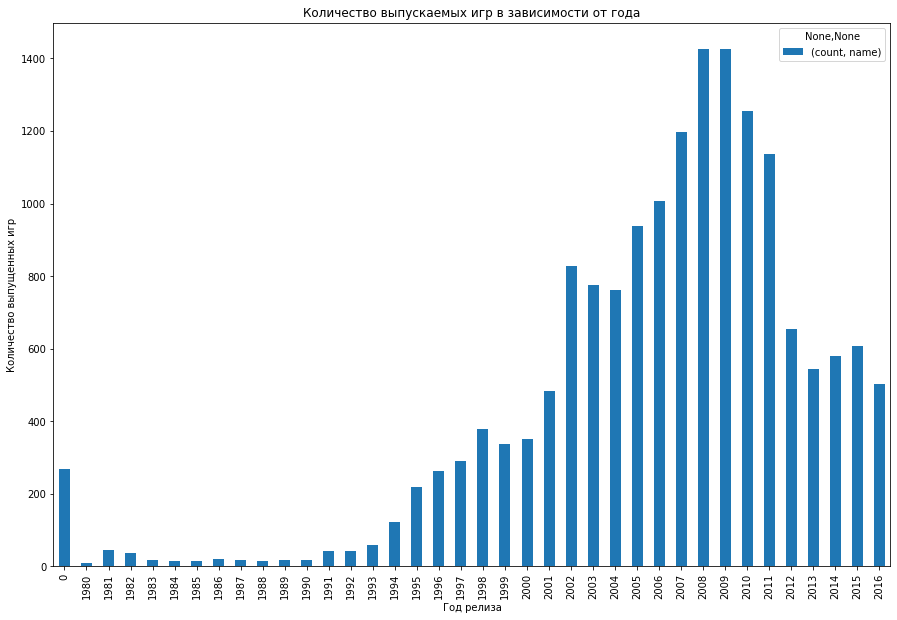

In [19]:
data_games.pivot_table(index='year_of_release', values='name', aggfunc=['count']).plot(kind='bar', figsize=(15, 10))
plt.title('Количество выпускаемых игр в зависимости от года')
plt.xlabel('Год релиза')
plt.ylabel('Количество выпущенных игр')
plt.show()

Наблюдаем положительную тенденцию по количеству выпуска игр до 2009 года включительно - количество выпущенных игр возрастает. Больше всего игр было выпущено в 2008 и 2009 году. После 2009 года количество игр начало снижаться, причем разница между 2010 и 2011 года очень большая, процентов на 40 в 2011 году игр было выпущено меньше. После 2011 года игры выпускались в примерно таком же количестве.

### Как менялись продажи по платформам

Выберем платформы с наибольшими суммарными продажами.

In [20]:
total_sale_platform = data_games.pivot_table(index=['platform'], values='total_sale_count', aggfunc=[np.sum])
total_sale_platform.columns = ['total_sale_count']
total_sale_platform = total_sale_platform.reset_index()
print(total_sale_platform.sort_values(by='total_sale_count', ascending=False).head(10))
top_platform = total_sale_platform.sort_values(by='total_sale_count', ascending=False).head(10)['platform'].unique()
top_platform

   platform  total_sale_count
16      PS2           1255.77
28     X360            971.42
17      PS3            939.65
26      Wii            907.51
4        DS            806.12
15       PS            730.86
6       GBA            317.85
18      PS4            314.14
19      PSP            294.05
13       PC            259.52


array(['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'GBA', 'PS4', 'PSP', 'PC'],
      dtype=object)

Построим распределение продаж по годам.

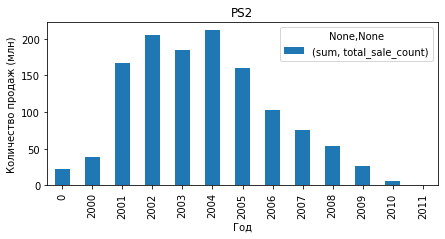

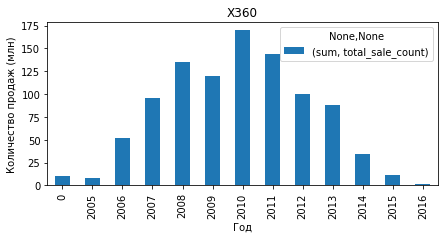

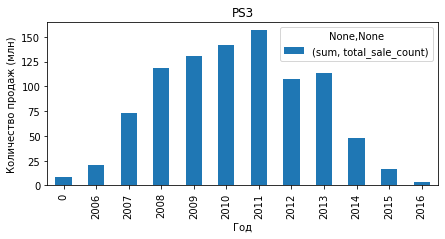

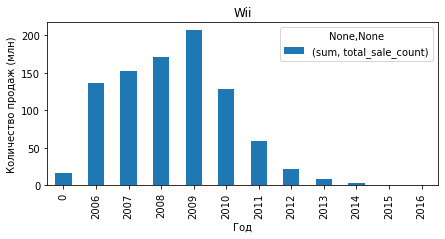

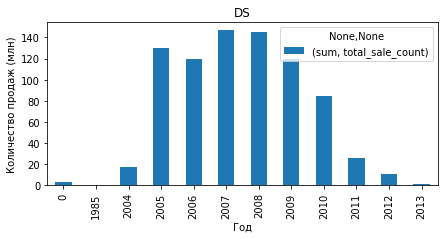

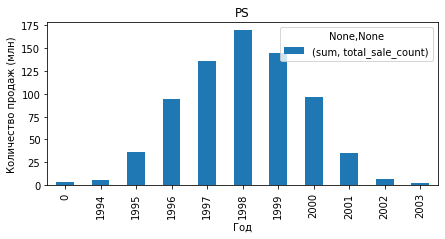

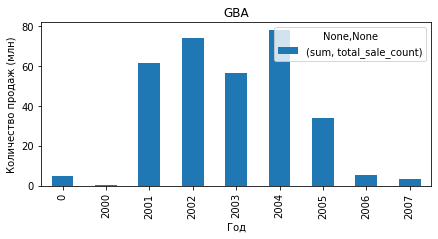

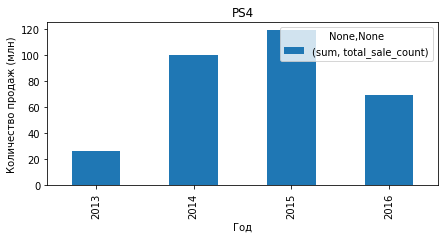

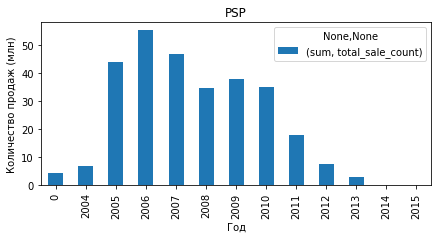

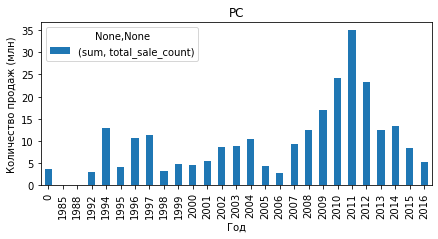

In [21]:
for platform in top_platform:
    data_games.loc[data_games['platform']==platform].pivot_table(index='year_of_release', 
                                                                 values='total_sale_count', 
                                                                 aggfunc=[np.sum]).plot(kind='bar', figsize=(7,3))
    plt.title(platform)
    plt.ylabel('Количество продаж (млн)')
    plt.xlabel('Год')
    plt.show()

В целом можно заметить такую тенденцию, что одно поколение платформы остается актуальным на рынке в течение 5-7 лет. PS2 (2001-2007), X360 (2007-2013), PS3 (2007-2013), Wii (2006-2010), DS (2005-2010), PS (1996-2000), GBA (2001-2005), PSP(2005-2011). Касаемо PC мы наблюдаем рост в период 2007-2011 год с пиком в 2011 год, в дальнейшем доля продаж для PC сокращалась. 

Также очень интересная последовательная картина наблюдается с поколонием PS. Как можно заметить, одно поколоние по популярности заменяет другое, что логично. Цепь такая: 

PS (1996-2000)->PS2 (2001-2007)->PS3 (2007-2013)->PS4 (2014-...)

Стоит отметить, что наибольшую популярность к 2016 году составляет именно платформа PS4, это надо учитывать, чтобы сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

### Изучим данные за последние 5 лет для выявления перспективных платформ

Теперь посмотрим, нет ли каких-нибудь еще популярных платформ, которые не попали в наш топ-10 платформ по сумме всех продаж по причине того, что они появились только недавно, но подают большие надежды.

In [22]:
data_games_5year = data_games.loc[data_games['year_of_release']>2011]
total_sale_platform_5y = data_games_5year.pivot_table(index=['platform'], values='total_sale_count', aggfunc=[np.sum])
total_sale_platform_5y.columns = ['total_sale_count']
total_sale_platform_5y = total_sale_platform_5y.reset_index()
total_sale_platform_5y.sort_values(by='total_sale_count', ascending=False)

,platform,total_sale_count
4,PS4,314.14
3,PS3,288.79
9,X360,236.54
0,3DS,194.61
10,XOne,159.32
8,WiiU,82.19
2,PC,62.65
6,PSV,49.18
7,Wii,35.37
1,DS,12.55


Про PS3, X360 уже шла речь, хоть эти платформы в топе нашего списка, но к 2016 году их популярность уже не такая высокая. Изучим среди этого списка еще две платформы: XOne и WiiU. Построим распределения по продажам. Также добавим график для PS4 для сравнения.

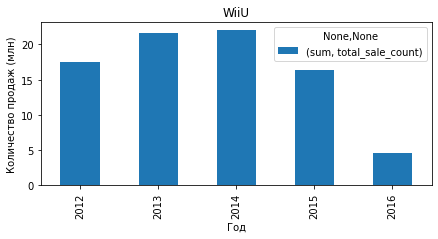

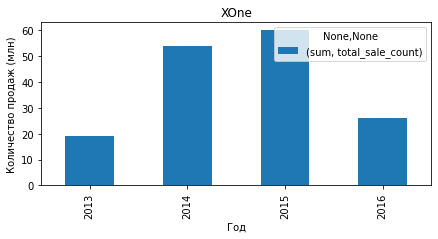

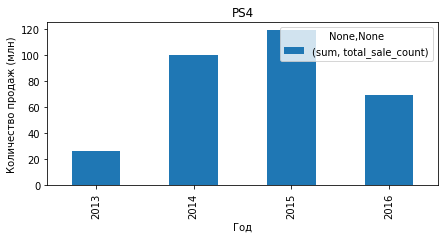

In [23]:
for platform in ['WiiU', 'XOne', 'PS4']:
    data_games.loc[data_games['platform']==platform].pivot_table(index='year_of_release', 
                                                                 values='total_sale_count', 
                                                                 aggfunc=[np.sum]).plot(kind='bar', figsize=(7,3))
    plt.title(platform)
    plt.ylabel('Количество продаж (млн)')
    plt.xlabel('Год')
    plt.show()

XOne подает хорошие надежды, WiiU сомнительно. Помним, что данные за 2016 неполные, поэтому судить только по нему не стоит. По итогу можно выделить **две перспективные платформы** - **XOne** и в особенности **PS4**. Также учитывая успех линейки PS и Xbox, PS4 и XOne должны хорошо держаться на рынке.

**В дальнейшей работе будем использовать датафрейм с данными за последние 5 лет, поскольку нам важно сделать прогноз на будущий год, данные за прошлый год нам нет смысла учитывать.**

### График «ящик с усами» по глобальным продажам игр в разбивке по платформам

Построим график «ящик с усами» по глобальным продажам игр в разбивке по наиболее перспективным платформам - PS4, XOne, WiiU.

In [37]:
data_games

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sale_count
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,0.0,0.0,Indefined,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,0.0,0.0,Indefined,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,0.0,0.0,Indefined,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,0.0,0.0,Indefined,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,0.0,0.0,Indefined,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,0.0,0.0,Indefined,0.01


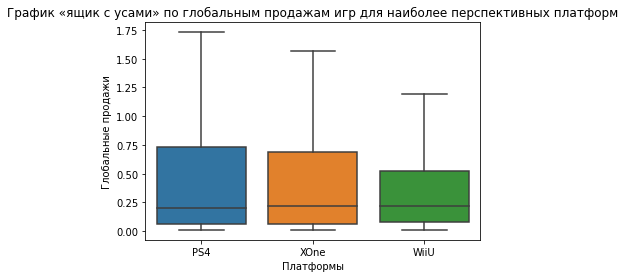

In [39]:
data_top3_platform = data_games[(data_games['platform']=='PS4')|(data_games['platform']=='XOne')|(data_games['platform']=='WiiU')]
sns.boxplot(data=data_top3_platform, x='platform', y='total_sale_count', showfliers=False)
plt.title('График «ящик с усами» по глобальным продажам игр для наиболее перспективных платформ')
plt.xlabel('Платформы')
plt.ylabel('Глобальные продажи')
plt.show()

Медианное значение у всех трех перспективных платформ почти одинаково, около 0.2. Однако все таки видно, что в случае с PS4 и XOne третий квартиль лежит выше, чем у WiiU, это значит, что количество игр с большим количество продаж в среднем выше у PS4 и XOne. 

### Как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков?

Построим диаграммы рассеяния зависимости количества продаж от отзыв пользователей и критиков для наиболее популярной платформы за последние 5 лет - PS4. Найдем корреляцию для каждого случая.

Корреляция равна: 0.406567902061781


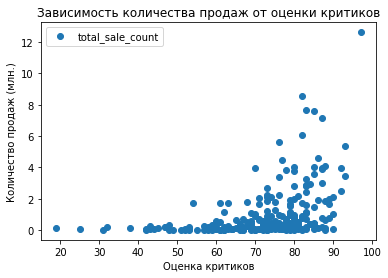

In [25]:
data_games_5year.loc[(data_games_5year['platform']=='PS4')&(data_games_5year['critic_score']>0)].plot(x='critic_score', y='total_sale_count', style='o')
plt.title('Зависимость количества продаж от оценки критиков')
plt.xlabel('Оценка критиков')
plt.ylabel('Количество продаж (млн.)')
print('Корреляция равна:', data_games_5year.loc[(data_games_5year['platform']=='PS4')&(data_games_5year['critic_score']>0), 'total_sale_count'].corr(data_games_5year['critic_score']))

Корреляция равна 0.4. Что ж, на графике это видно, количество продаж для игр с оценкой критиков до 70 лежит в районе 0-2 миллионов, продажи почти не меняются. А начиная с 70 и далее уже идет подозрение на прямую корреляцию, видно, что с повышением оценки количество продаж увеличивается.

Корреляция равна: -0.031957110204556376


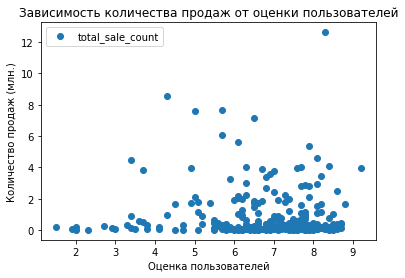

In [26]:
data_games_5year.loc[(data_games_5year['platform']=='PS4')&(data_games_5year['user_score']>0)].plot(x='user_score', y='total_sale_count', style='o')
plt.title('Зависимость количества продаж от оценки пользователей')
plt.xlabel('Оценка пользователей')
plt.ylabel('Количество продаж (млн.)')
print('Корреляция равна:', data_games_5year.loc[(data_games_5year['platform']=='PS4')&(data_games_5year['user_score']>0), 'total_sale_count'].corr(data_games_5year['user_score']))

Корреляция почти равна 0. На графике видно, что оценка пользователей может быть маленькой, а продажи высокие, а с высокой оценкой продажи могут быть низкими. Достаточно хаотичная зависимость. Можно предположить, что низкие оценки и высокие продажи обусловены тем, что пользователи сначал яро покупали игру, а потом уже ставили низкий рейтинг, отсюда такой на первый взгляд феномен.

Посмотрим на другие популярные платформы, похожая ли там картина или нет.

In [27]:
for platform in top_platform:
    cor_1 = data_games.\
          loc[(data_games['platform']==platform)&(data_games['critic_score']>0), 'total_sale_count'].\
          corr(data_games['critic_score'])
    cor_2 = data_games.\
          loc[(data_games['platform']==platform)&(data_games['user_score']>0), 'total_sale_count'].\
          corr(data_games['user_score'])
    print(f'Корреляция количества продаж от оценки критиков для платформы {platform} равна {cor_1}')
    print(f'Корреляция количества продаж от оценки пользователей для платформы {platform} равна {cor_2}\n')

Корреляция количества продаж от оценки критиков для платформы PS2 равна 0.3954345494545487
Корреляция количества продаж от оценки пользователей для платформы PS2 равна 0.17286551112058224

Корреляция количества продаж от оценки критиков для платформы X360 равна 0.3937358653072584
Корреляция количества продаж от оценки пользователей для платформы X360 равна 0.11445882978454186

Корреляция количества продаж от оценки критиков для платформы PS3 равна 0.4324315685642063
Корреляция количества продаж от оценки пользователей для платформы PS3 равна 0.12669133936341692

Корреляция количества продаж от оценки критиков для платформы Wii равна 0.17755988806089956
Корреляция количества продаж от оценки пользователей для платформы Wii равна 0.11241436067003162

Корреляция количества продаж от оценки критиков для платформы DS равна 0.23637945738859772
Корреляция количества продаж от оценки пользователей для платформы DS равна 0.13293777533153114

Корреляция количества продаж от оценки критиков для п

Как можно заметить, корреляции количества продаж от оценки критиков для наиболее популярных платформ в целом похожи между собой и лежат в районе 40% (PS2, X360, PS3, PS, PS4). Корреляция количества продаж от оценки пользователей остается в пределе 10-20% для всех платформ кроме PS, но данная платформа для нас интереса не несет, поскольку достаточно старая.

### Общее распределение игр по жанрам

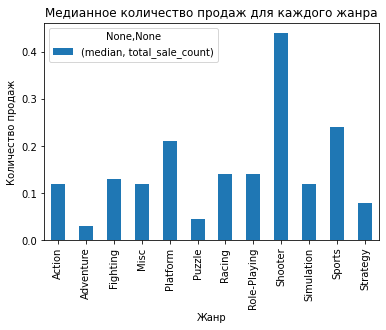

In [28]:
data_games_5year.pivot_table(index='genre', values='total_sale_count', aggfunc=['median']).plot(kind='bar')
plt.title('Медианное количество продаж для каждого жанра')
plt.xlabel('Жанр')
plt.ylabel('Количество продаж')
plt.show()

Безусловно видно, что за последние 5 лет наиболее **стабильный по популярности жанр** это **Shooter**. За ним идут **Sports и Platform**. Меньше всего продаются Adventure и Puzzle.

**Вывод:**
1. Больше всего игр было выпущено в 2008-2009 году. После 2010-2011 года наблюдается снижение количества выпущенных игр. За период 2012-2016 год количество выпущенных игр несильно различается(500-600 штук)
2. В целом можно заметить такую тенденцию, что одно поколение платформы остается актуальным на рынке в течение 5-7 лет
3. Наиболее популярные платформы за весь период PS2, X360, PS3, Wii
4. За последние 5 лет наиболее популярные и перспективные платформы это PS4, XOne и WiiU (преимущественно в регионе EU)
5. Отзывы критиков больше влияют на продажи внутри платформы, чем отзывы пользователей. В целом, проводить корреляцию между отзывами пользователей и продажами не совсем правильно, поскольку на пиар игры могли вложить много сил, пользователи с азартом покупают игры, но в итоге, разочаровавшись, ставят плохие оценки. Также может быть и наоборот, продаж мало, а игра по отзывам хорошая
6. За последние 5 лет наиболее стабильный популярный и прибыльный жанр это Shooter. За ним идут Sports и Platform. Меньше всего продаются Adventure и Puzzle.

##  Портрет пользователя каждого региона

Определим для пользователя каждого региона (NA, EU, JP):
- Самые популярные платформы (топ-5).
- Самые популярные жанры (топ-5).
- Влияет ли рейтинг ESRB на продажи в отдельном регионе?

### Самые популярные платформы (топ-5)

С помощью сводной таблицы найдем общую сумму продаж для каждой платформы для каждого региона и построим графики популярности.

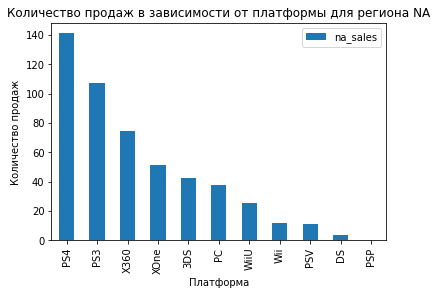

4      PS4
3      PS3
9     X360
10    XOne
0      3DS
Name: platform, dtype: object


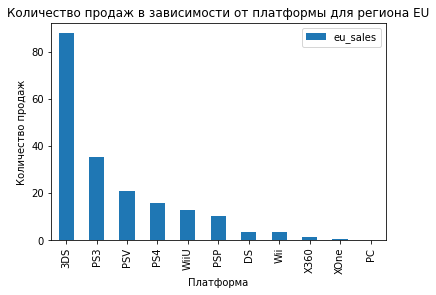

0     3DS
3     PS3
6     PSV
4     PS4
8    WiiU
Name: platform, dtype: object


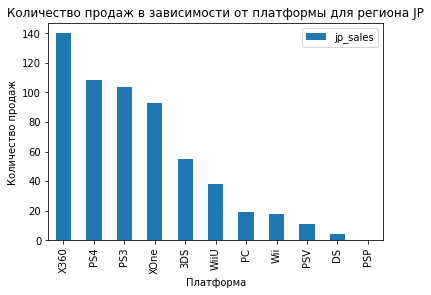

9     X360
4      PS4
3      PS3
10    XOne
0      3DS
Name: platform, dtype: object


In [29]:
top_5_platform = data_games_5year.pivot_table(index='platform', values=['na_sales', 'eu_sales', 'jp_sales'], aggfunc=[np.sum])
top_5_platform.columns = ['na_sales', 'eu_sales', 'jp_sales']
top_5_platform = top_5_platform.reset_index()
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    top_5_platform.sort_values(by=region, ascending=False).plot.bar(x='platform', y=region)
    plt.title(f'Количество продаж в зависимости от платформы для региона {region.split("_")[0].upper()}')
    plt.xlabel('Платформа')
    plt.ylabel('Количество продаж')
    plt.show()
    print(top_5_platform.sort_values(by=region, ascending=False).head()['platform'])

Как видно, наиболее популярные платформы для каждого региона это:
- NA - PS4, PS3, X360, XOne, 3DS
- EU - 3DS, PS3, PSV, PS4, WiiU
- JP - X360, PS4, PS3, XOne, 3DS

В регионе NA и JP топ-5 платформ похожи, разница лишь в расположении, топ-3 для NA это PS4, PS3, X360, для JP - X360, PS4, PS3. В EU же наиболее популярная платформа это 3DS, которая в остальных регионах только на 5 месте по популярности. Однако стоит учитывать этот факт, судя по всему, в глобальном плане 3DS не так популярна, как линейки PS и Xbox, однако в локальном плане данная платформа очень популярна в регионе EU.

### Самые популярные жанры (топ-5)

С помощью сводной таблицы найдем общую сумму продаж для каждого жанра для каждого региона и построим графики популярности.

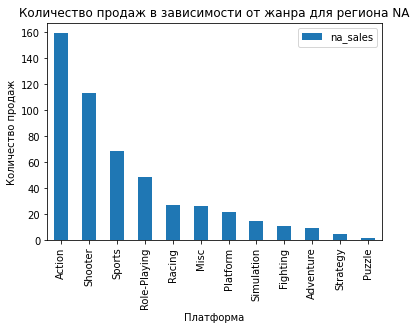

0           Action
8          Shooter
10          Sports
7     Role-Playing
6           Racing
Name: genre, dtype: object


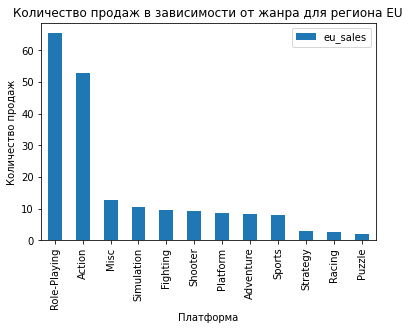

7    Role-Playing
0          Action
3            Misc
9      Simulation
2        Fighting
Name: genre, dtype: object


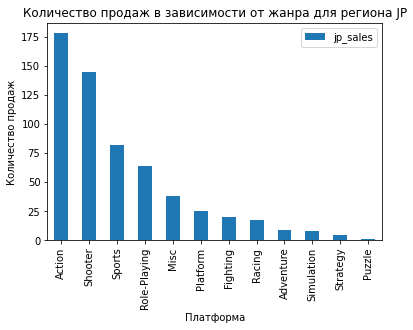

0           Action
8          Shooter
10          Sports
7     Role-Playing
3             Misc
Name: genre, dtype: object


In [30]:
top_5_genre = data_games_5year.pivot_table(index='genre', values=['na_sales', 'eu_sales', 'jp_sales'], aggfunc=[np.sum])
top_5_genre.columns = ['na_sales', 'eu_sales', 'jp_sales']
top_5_genre = top_5_genre.reset_index()
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    top_5_genre.sort_values(by=region, ascending=False).plot.bar(x='genre', y=region)
    plt.title(f'Количество продаж в зависимости от жанра для региона {region.split("_")[0].upper()}')
    plt.xlabel('Платформа')
    plt.ylabel('Количество продаж')
    plt.show()
    print(top_5_genre.sort_values(by=region, ascending=False).head()['genre'])

Как видно, наиболее популярные жанры для каждого региона это:
- NA - Action, Shooter, Sports, Role-Playing, Racing
- EU - Role-playing, Action, Misc, Simulation, Fighting
- JP - Action, Shooter, Sports, Role-Playing, Misc

Видно, что наиболее популярные жанры в регионах NA и JP практически совпал, наиболее популярны там Action, Shooter и Sports. В регионе EU же наиболее популярные рейтинги это Role-playing, Action и Misc.

### Зависимость продаж от рейтинга для региона

С помощью сводной таблицы найдем общую сумму продаж для каждого жанра для каждого региона и построим графики популярности. Перед построением графиков не будем учитывать рейтинг, который неопределен в силу каких-то обстоятельств.

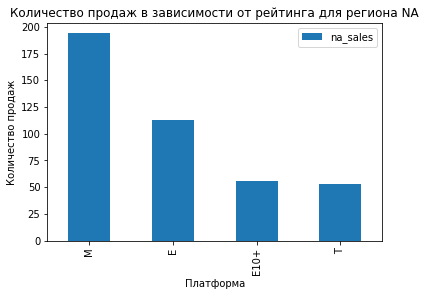

3       M
0       E
1    E10+
4       T
Name: rating, dtype: object


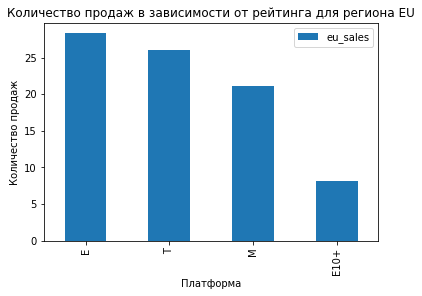

0       E
4       T
3       M
1    E10+
Name: rating, dtype: object


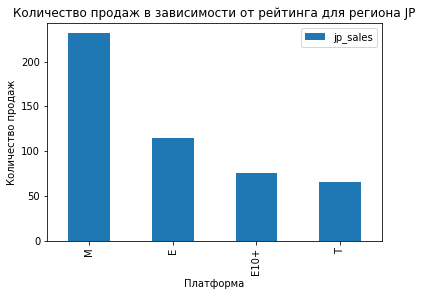

3       M
0       E
1    E10+
4       T
Name: rating, dtype: object


In [31]:
top_rating = data_games_5year.pivot_table(index='rating', values=['na_sales', 'eu_sales', 'jp_sales'], aggfunc=[np.sum])
top_rating.columns = ['na_sales', 'eu_sales', 'jp_sales']
top_rating = top_rating.reset_index()
top_rating = top_rating[top_rating['rating']!='Indefined']
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    top_rating.sort_values(by=region, ascending=False).plot.bar(x='rating', y=region)
    plt.title(f'Количество продаж в зависимости от рейтинга для региона {region.split("_")[0].upper()}')
    plt.xlabel('Платформа')
    plt.ylabel('Количество продаж')
    plt.show()
    print(top_rating.sort_values(by=region, ascending=False).head()['rating'])

Как видно, наиболее популярные рейтинги для каждого региона это:
- NA - M, E, E10+, T
- EU - E, T, M, E10+
- JP - M, E, E10+, T

Популярные рейтинги для регионов NA и JP идентичны, наиболее популярный это рейтинг M, а вот в регионе EU наиболее популярный рейтинг E.

**Вывод:**
- Для региона NA и JP в топ 5 платформ попали одни и те же позиции (в порядке убывания популярности) - (PS4, PS3, X360, XOne, 3DS) для NA и (X360, PS4, PS3, XOne, 3DS) для JP, топ 5 жанров практически совпал (в порядке убывания популярности) - (Action, Shooter, Sports, Role-Playing, Racing) для NA и (Action, Shooter, Sports, Role-Playing, Misc) для JP, а наиболее популярные рейтинги идентичны (в порядке убывания популярности) - (M, E, E10+, T)
- Для региона EU картина иная, он мало чем похож на NA и JP. Топ 5 популярных платформ - (3DS, PS3, PSV, PS4, WiiU), топ 5 популярных жанров для EU - (Role-playing, Action, Misc, Simulation, Fighting), наиболее популярные рейтинги (в порядке убывания популярности) - (E, T, M, E10+)
- Рейтинг ESRB влияет на продажи в отдельном регионе, например в регионе EU наиболее популярный рейтинг это E, в NA и JP это M

## Проверка гипотез

Проверим поставленные гипотезы:
- Средние пользовательские рейтинги платформ Xbox One и PC одинаковые;
- Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.

Перед проверкой зададим пороговое значение alpha

In [32]:
alpha = 0.05

### Средние пользовательские рейтинги платформ Xbox One и PC одинаковые

Для проверки данной гипотезы мы используем двусторонний двухвыборочный t-тест для независимых выборок. Нулевая гипотеза - средние пользовательские рейтинги платформ Xbox One и PC равны, альтернативная гипотеза - рейтинги не равны (значимо различаются).

In [33]:
result_1 = st.ttest_ind(data_games_5year.loc[(data_games_5year['platform']=='XOne') & \
                                             (data_games_5year['user_score']!=0),'user_score'], 
                        data_games_5year.loc[(data_games_5year['platform']=='PC') & \
                                             (data_games_5year['user_score']!=0), 'user_score'])
if alpha>result_1.pvalue:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нулевую гипотезу не получилось отвергнуть')
print(result_1.pvalue)

Нулевую гипотезу не получилось отвергнуть
0.5535080500643661


Не отвергаем нулевую гипотезу о равенстве средних пользовательских рейтингов платформ Xbox One и PC, причем pvalue достаточно высок.

### Средние пользовательские рейтинги жанров Action  и Sports разные

Для проверки данной гипотезы мы используем двусторонний двухвыборочный t-тест для независимых выборок. Нулевая гипотеза - средние пользовательские рейтинги жанров Action и Sports равны, альтернативная гипотеза - рейтинги не равны (значимо различаются).

In [34]:
result_2 = st.ttest_ind(data_games_5year.loc[(data_games_5year['genre']=='Action') & \
                                             (data_games_5year['user_score']!=0), 'user_score'], 
                        data_games_5year.loc[(data_games_5year['genre']=='Sports') & \
                                             (data_games_5year['user_score']!=0), 'user_score'])
if alpha>result_2.pvalue:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нулевую гипотезу не получилось отвергнуть')
print(result_2.pvalue)

Отвергаем нулевую гипотезу
3.7163089460934874e-26


Нулевая гипотеза отвергнута, значение p-value очень мало, значит мы можем утверждать, что средние пользовательские рейтинги жанров Action и Sports действительно разные, поскольку мы отвергли нулевую гипотезу об их равенстве.

**Вывод:**
- Не отвергаем гипотезу о равенстве средних пользовательских рейтингов платформ Xbox One и PC, pvalue достаточно высок.
- Можно утверждать, что средние пользовательские рейтинги жанров Action и Sports разные, pvalue очень мал.

## Общий вывод

В ходе проделанной работы мы выполнили следующие задачи:
1. Изучили общую информацию о данных
2. Предобработали и подготовили данные для дальнейшей работы
3. Провели исследовательских анализ данных по требуемым запросам
4. Составили портрет пользователя для каждого региона
5. Проверили требуемые гипотезы

И пришли к следующим выводам:
1. В результате обработки данных мы столкнулись с множествами пропусков в столбцах (до половины пропущенных данных от всего количества) 'critic_score', 'user_score', 'rating'. Данные столбцы несут достаточно важную информацию, особенно первые два из перечисленных. Однако предположив, что рейтинги не могут стоять по причине того, что игры просто не оценивали, заменили пропуски на 0 и продолжили исследование дальше. Рейтинг мог не стоять по той же причине.
2. Больше всего игр было выпущено в 2008-2009 году. После 2010-2011 года наблюдается снижение количества выпущенных игр. За период 2012-2016 год количество выпущенных игр несильно различается(500-600 штук). В целом можно заметить такую тенденцию, что одно поколение платформы остается актуальным на рынке в течение 5-7 лет.
3. За последние 5 лет наиболее популярные и перспективные платформы это PS4, XOne и WiiU (преимущественно в регионе EU)
4. Отзывы критиков больше влияют на продажи внутри платформы, чем отзывы пользователей.
5. За последние 5 лет наиболее популярный и прибыльный жанр это Action. За ним идут Shooter, Role-Playing и Sports. Меньше всего продаются Strategy и Puzzle.
6. В регионе NA и JP похожие вкусы и интересы. В топ 5 платформ попали одни и те же позиции - (PS4, PS3, X360, XOne, 3DS) для NA и (X360, PS4, PS3, XOne, 3DS), топ 5 жанров практически совпал - (Action, Shooter, Sports, Role-Playing, Racing) для NA и (Action, Shooter, Sports, Role-Playing, Misc) для JP.
7. Для региона EU картина иная, он мало чем похож на NA и JP. Топ 5 популярных платформ - (3DS, PS3, PSV, PS4, WiiU), топ 5 популярных жанров для EU - (Role-playing, Action, Misc, Simulation, Fighting).
8. Рейтинг ESRB влияет на продажи в отдельном регионе, например в регионе EU наиболее популярный рейтинг это E, в NA и JP это M.
9. Не отвергаем гипотезу о равенстве средних пользовательских рейтингов платформ Xbox One и PC. Также можно утверждать, что средние пользовательские рейтинги жанров Action и Sports разные.

**Итог:** стоит делать акцент на платформах PS4, XOne - для работы на рынках NA и JP, а также WiiU - для работы на рынке EU. Стоит обратить внимания на жанры Shooter, Platform, Sports - они наиболее стабильные по популярности. Стоит учитывать, что наиболее популярный рейтинг для регионов NA и JP это M, а для EU - E.